In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import pylab
from astropy.io import fits
from astropy.wcs import WCS
import os
from astropy.utils.data import get_pkg_data_filename
import GMIMS_CGPS_subroutines as subs
import importlib as imp
import scipy
import scipy.signal
from scipy.stats import spearmanr
import math
import os
import subprocess
from astropy.visualization.wcsaxes.frame import EllipticalFrame
from reproject import reproject_interp
import time
import random

In [2]:
names = ('GMIMS full range RM Synthesis Peaks', 
         '1280 - 1370 MHz RM Synthesis Peaks',
         '1400 - 1440 MHz RM Synthesis Peaks',
         '1320 - 1360 MHz RM Synthesis Peaks',
         '1400 - 1520 MHz RM Synthesis Peaks', 
         '1440 - 1480 MHz RM Synthesis Peaks')
         
#=========== Read in files:=============================================
directories = ('../GMIMS_SUMMER2019/RM_SYNTH/RFI_FIX_v3/',
               '../GMIMS_SUMMER2019/GMIMS_4BANDS/MINI_V6/',
               '../GMIMS_SUMMER2019/GMIMS_4BANDS/MINI_V5/',
               '../GMIMS_SUMMER2019/GMIMS_4BANDS/MINI_V1/',
               '../GMIMS_SUMMER2019/GMIMS_4BANDS/MINI_V2/', 
               '../GMIMS_SUMMER2019/GMIMS_4BANDS/MINI_V3/',)

sdir = np.size(directories)

datacubes = [None] * sdir
datapeaks = [None] * sdir
dataRMSFs = [None] * sdir

hdu1 = fits.open(directories[0]+'FDF_clean_tot.fits')
hdu2 = fits.open(directories[0]+'CLEAN_peakRM.fits')
hdu3 = fits.open(directories[0]+'RMSF_tot.fits')
hdr1 = hdu1[0].header
hdr2 = hdu2[0].header
hdr3 = hdu3[0].header
datacubes[0] = hdu1[0].data
datapeaks[0] = hdu2[0].data[0,:,:]
dataRMSFs[0] = hdu3[0].data

lon_full, lat_full, RM_full = subs.make_axis_lists_3D(hdr1)
lon_full_RMSF, lat_full_RMSF, RM_full_RMSF = subs.make_axis_lists_3D(hdr3)

for i in range(1,sdir):    
    hdu1 = fits.open(directories[i]+'FDF_clean_tot.fits')
    hdu2 = fits.open(directories[i]+'CLEAN_peakRM.fits')
    hdu3 = fits.open(directories[i]+'RMSF_tot.fits')
    hdr1 = hdu1[0].header
    hdr2 = hdu2[0].header
    hdr3 = hdu3[0].header
    datacubes[i] = hdu1[0].data
    datapeaks[i] = hdu2[0].data
    dataRMSFs[i] = hdu3[0].data


lon_mini, lat_mini, RM_mini = subs.make_axis_lists_3D(hdr1)
lon_mini_RMSF, lat_mini_RMSF, RM_mini_RMSF = subs.make_axis_lists_3D(hdr3)


############### Making Mollweide mask =======================
basic_hdr = hdr2.copy()

del basic_hdr['CUNIT3']

# Correct the pixels for astropy:
basic_hdr['CRVAL1'] = 0.
basic_hdr['CRVAL2'] = 0.
basic_hdr['CRPIX1'] = 361
basic_hdr['CRPIX2'] = 181

# New header for the MOL projection:
mol_hdr = basic_hdr.copy()
mol_hdr['CTYPE1'] = 'GLON-MOL'
mol_hdr['CTYPE2'] = 'GLAT-MOL'

mask_data = datapeaks[1].copy()
wnan = np.where(np.isnan(mask_data))
mask_data[wnan] = -9999.
mask_mol, footprint = reproject_interp((mask_data,basic_hdr), mol_hdr)
wblack = np.where(~np.isnan(mask_mol))
mask_mol[wblack] = 0.

#================== Flatten data for histograms =========================
mapvec = [datapeaks[0].flatten(), datapeaks[1].flatten(),
          datapeaks[2].flatten(), datapeaks[3].flatten(),
          datapeaks[4].flatten(), datapeaks[5].flatten()]

print(RM_full)

/usr/lib64/python2.7/site-packages/reproject/interpolation/core_celestial.py:26: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  if not np.issubdtype(array.dtype, np.float):
/home/aordog/.local/lib/python2.7/site-packages/astropy/coordinates/angles.py:651: RuntimeWarning: invalid value encountered in less
  if np.any(self_angle < wrap_angle_floor) or np.any(self_angle >= wrap_angle):
/home/aordog/.local/lib/python2.7/site-packages/astropy/coordinates/angles.py:651: RuntimeWarning: invalid value encountered in greater_equal
  if np.any(self_angle < wrap_angle_floor) or np.any(self_angle >= wrap_angle):
/home/aordog/.local/lib/python2.7/site-packages/astropy/coordinates/angles.py:534: RuntimeWarning: invalid value encountered in less
  if np.any(angles.value < lower) or np.any(angles.value > upper):
/home/aordog/.local/lib/python2.7/site-packages/astropy/co

[-2500. -2495. -2490. ...  2490.  2495.  2500.]


/usr/lib64/python2.7/site-packages/reproject/interpolation/core_celestial.py:150: RuntimeWarning: invalid value encountered in greater
  reset = (np.abs(xp_out - xp_out_check) > 1) | (np.abs(yp_out - yp_out_check) > 1)
/usr/lib64/python2.7/site-packages/reproject/array_utils.py:85: RuntimeWarning: invalid value encountered in less
  reset |= (coords[i] < -0.5)
/usr/lib64/python2.7/site-packages/reproject/array_utils.py:86: RuntimeWarning: invalid value encountered in greater
  reset |= (coords[i] > image.shape[i] - 0.5)


In [37]:
xsize = 720
ysize = 360
PIpeaks = np.empty((6,ysize,xsize))

wgood = np.where(abs(RM_full<=600.))[0]
for i in range(0,720):
    for j in range(0,360):
        PIpeaks[0,j,i] = np.max(datacubes[0][wgood,j,i])


wgood = np.where(abs(RM_mini)<=600.)[0]
for k in range(1,6):
    print(k)
    for i in range(0,720):
        for j in range(0,360):
            PIpeaks[k,j,i] = np.max(datacubes[k][wgood,j,i])



1
2
3
4
5


In [ ]:
names = ('GMIMS full range RM Synthesis Peaks', 
         '1280 - 1370 MHz RM Synthesis Peaks',
         '1400 - 1520 MHz RM Synthesis Peaks',
         '1320 - 1360 MHz RM Synthesis Peaks',
         '1400 - 1440 MHz RM Synthesis Peaks', 
         '1440 - 1480 MHz RM Synthesis Peaks')

subplots = [321,323,325,322,324,326]

fs = 16
RMmax = 100.
#cmap = cm.nipy_spectral
cmap = cm.RdBu
cmap.set_bad(alpha=0.)

fig = plt.figure(figsize=(20,20))
plt.subplots_adjust(hspace=0.01)
plt.subplots_adjust(wspace=0.01)

for j in range(0,6):
    
    i = subplots[j]
    
    array_mol, footprint = reproject_interp((datapeaks[j],basic_hdr), mol_hdr)
    wcs_mol = WCS(mol_hdr)
            
    ax = fig.add_subplot(i,projection=wcs_mol, frame_class=EllipticalFrame)
    im1 = ax.imshow(mask_mol,vmin=0.,vmax=1.,origin='lower',cmap='gray')
    im2 = ax.imshow(array_mol,vmin=-RMmax,vmax=RMmax,origin='lower',cmap=cmap)
    ax.set_title(names[j],fontsize=fs)

    ax.coords.frame.set_linewidth(0)
    lon = ax.coords[0]; lat = ax.coords[1]

    lon.set_axislabel('Galactic Longitude',fontsize=fs, minpad=9)
    lat.set_axislabel('Galactic Latitude',fontsize=fs, minpad=-2)
    lon.set_axislabel_position('h')
    lat.set_axislabel_position('c')

    lon.set_ticks(number=13,color='w')
    lat.set_ticks(number=11,color='w') 
    lon.set_ticklabel(color='grey', size=fs)
    lat.set_ticklabel(color='grey', size=fs)
    lat.set_ticklabel_position('v')

    lon.grid(color='grey', linestyle='solid')
    lat.grid(color='grey', linestyle='solid')

    cb = fig.colorbar(im2,orientation='horizontal',shrink = 0.5, pad=0.05)
    cb.set_label(label='rad m$^{-2}$',size=fs)
    cb.ax.tick_params(labelsize=fs)
plt.tight_layout()
plt.savefig('FIGURES/GMIMS_FREQ_RANGE_MAPS_PEAKS.pdf')

In [38]:
reload(subs)

M1_files = [None] * sdir
M0_files = [None] * sdir

perc = 0.15
peakthresh = 0.04


maxFD = 600.
M0_files[0],M0hdr = subs.zero_moment_v2(hdr3,datacubes[0],PIpeaks[0,:,:],peakthresh,maxFD,perc,
                                        lon_full,lat_full,RM_full,5.)
M1_files[0],M1hdr = subs.first_moment_v2(hdr3,datacubes[0],PIpeaks[0,:,:],peakthresh,maxFD,perc,
                                         lon_full,lat_full,RM_full,5.,M0_files[0])

for i in range(1,3):
    M0_files[i],M0hdr = subs.zero_moment_v2(hdr3,datacubes[i],PIpeaks[i,:,:],peakthresh,maxFD,perc,
                                            lon_full,lat_full,RM_mini,10.)
    M1_files[i],M1hdr = subs.first_moment_v2(hdr3,datacubes[i],PIpeaks[i,:,:],peakthresh,maxFD,perc,
                                             lon_full,lat_full,RM_mini,10.,M0_files[i])
    

maxFD = 1000.
for i in range(3,6):
    M0_files[i],M0hdr = subs.zero_moment_v2(hdr3,datacubes[i],PIpeaks[i,:,:],peakthresh,maxFD,perc,
                                            lon_full,lat_full,RM_mini,10.)
    M1_files[i],M1hdr = subs.first_moment_v2(hdr3,datacubes[i],PIpeaks[i,:,:],peakthresh,maxFD,perc,
                                             lon_full,lat_full,RM_mini,10.,M0_files[i])

Calculating zeroth moment...
(720, 360)


GMIMS_CGPS_subroutines.py:494: RuntimeWarning: invalid value encountered in greater_equal
  zero_mom_data[j,i] = np.nansum(dFD*dataSlice[dataSlice >= comparer])


halfway
done

Calculating first moment...
(720, 360)


GMIMS_CGPS_subroutines.py:532: RuntimeWarning: invalid value encountered in greater_equal
  first_mom_data[j,i] = dFD*dataSliceRM[dataSlice >= comparer].sum()/zero_mom[j,i]
GMIMS_CGPS_subroutines.py:532: RuntimeWarning: invalid value encountered in double_scalars
  first_mom_data[j,i] = dFD*dataSliceRM[dataSlice >= comparer].sum()/zero_mom[j,i]


halfway
done

Calculating zeroth moment...
(720, 360)
halfway
done

Calculating first moment...
(720, 360)
halfway
done

Calculating zeroth moment...
(720, 360)
halfway
done

Calculating first moment...
(720, 360)
halfway
done

Calculating zeroth moment...
(720, 360)
halfway
done

Calculating first moment...
(720, 360)
halfway
done

Calculating zeroth moment...
(720, 360)
halfway
done

Calculating first moment...
(720, 360)
halfway
done

Calculating zeroth moment...
(720, 360)
halfway
done

Calculating first moment...
(720, 360)
halfway
done



In [40]:
mapvecM1 = [M1_files[0].flatten(), M1_files[1].flatten(),
            M1_files[2].flatten(), M1_files[3].flatten(),
            M1_files[4].flatten(), M1_files[5].flatten()]

259200
259200
6.103515625e-05
259200
259200
8.232284380937926e-05


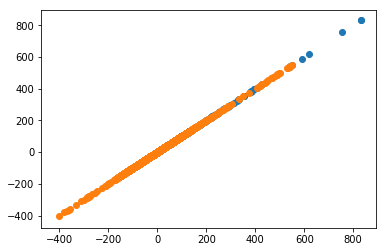

In [41]:
zero_mom_old_hdu = fits.open('../GMIMS_CGPS_WINTER2020/CODE/MOMENTS/zeroth_moment_Jun0520.fits')
zero_mom_old = zero_mom_old_hdu[0].data

plt.scatter(zero_mom_old,M0_files[0])

print(np.size(np.isfinite(zero_mom_old)))
print(np.size(np.isfinite(M0_files[0])))
print(np.nanmax(abs(zero_mom_old-M0_files[0])))

first_mom_old_hdu = fits.open('../GMIMS_CGPS_WINTER2020/CODE/MOMENTS/first_moment_Mar2920.fits')
first_mom_old = first_mom_old_hdu[0].data

plt.scatter(first_mom_old,M1_files[0])

print(np.size(np.isfinite(first_mom_old)))
print(np.size(np.isfinite(M1_files[0])))
print(np.nanmax(abs(first_mom_old-M1_files[0])))

In [ ]:
names = ('GMIMS full range', 
         '1280 - 1370 MHz',
         '1400 - 1520 MHz',
         '1320 - 1360 MHz',
         '1400 - 1440 MHz', 
         '1440 - 1480 MHz')

subplots = [321,323,325,322,324,326]

fs = 16
RMmax = 100.
#cmap = cm.nipy_spectral
cmap = cm.RdBu
cmap.set_bad(alpha=0.)

fig = plt.figure(figsize=(20,20))
plt.subplots_adjust(hspace=0.01)
plt.subplots_adjust(wspace=0.01)

for j in range(0,6):
    
    i = subplots[j]
    
    array_mol, footprint = reproject_interp((M1_files[j],basic_hdr), mol_hdr)
    wcs_mol = WCS(mol_hdr)
            
    ax = fig.add_subplot(i,projection=wcs_mol, frame_class=EllipticalFrame)
    im1 = ax.imshow(mask_mol,vmin=0.,vmax=1.,origin='lower',cmap='gray')
    im2 = ax.imshow(array_mol,vmin=-RMmax,vmax=RMmax,origin='lower',cmap=cmap)
    ax.set_title(names[j],fontsize=fs)

    ax.coords.frame.set_linewidth(0)
    lon = ax.coords[0]; lat = ax.coords[1]

    lon.set_axislabel('Galactic Longitude (degrees)',fontsize=fs, minpad=9)
    lat.set_axislabel('Galactic Latitude \n (degrees)',fontsize=fs, minpad=-2)
    lon.set_axislabel_position('h')
    lat.set_axislabel_position('c')

    lon.set_ticks(number=13,color='w')
    lat.set_ticks(number=11,color='w') 
    lon.set_ticklabel(color='darkgrey', size=fs)
    lat.set_ticklabel(color='darkgrey', size=fs)
    lat.set_ticklabel_position('v')

    lon.grid(color='darkgrey', linestyle='solid')
    lat.grid(color='darkgrey', linestyle='solid')

    cb = fig.colorbar(im2,orientation='horizontal',shrink = 0.5, pad=0.05)
    cb.set_label(label='rad m$^{-2}$',size=fs)
    cb.ax.tick_params(labelsize=fs)
plt.tight_layout()
plt.savefig('FIGURES/GMIMS_FREQ_RANGE_MAPS_MOM1.pdf')

(1003,)
(2003,)


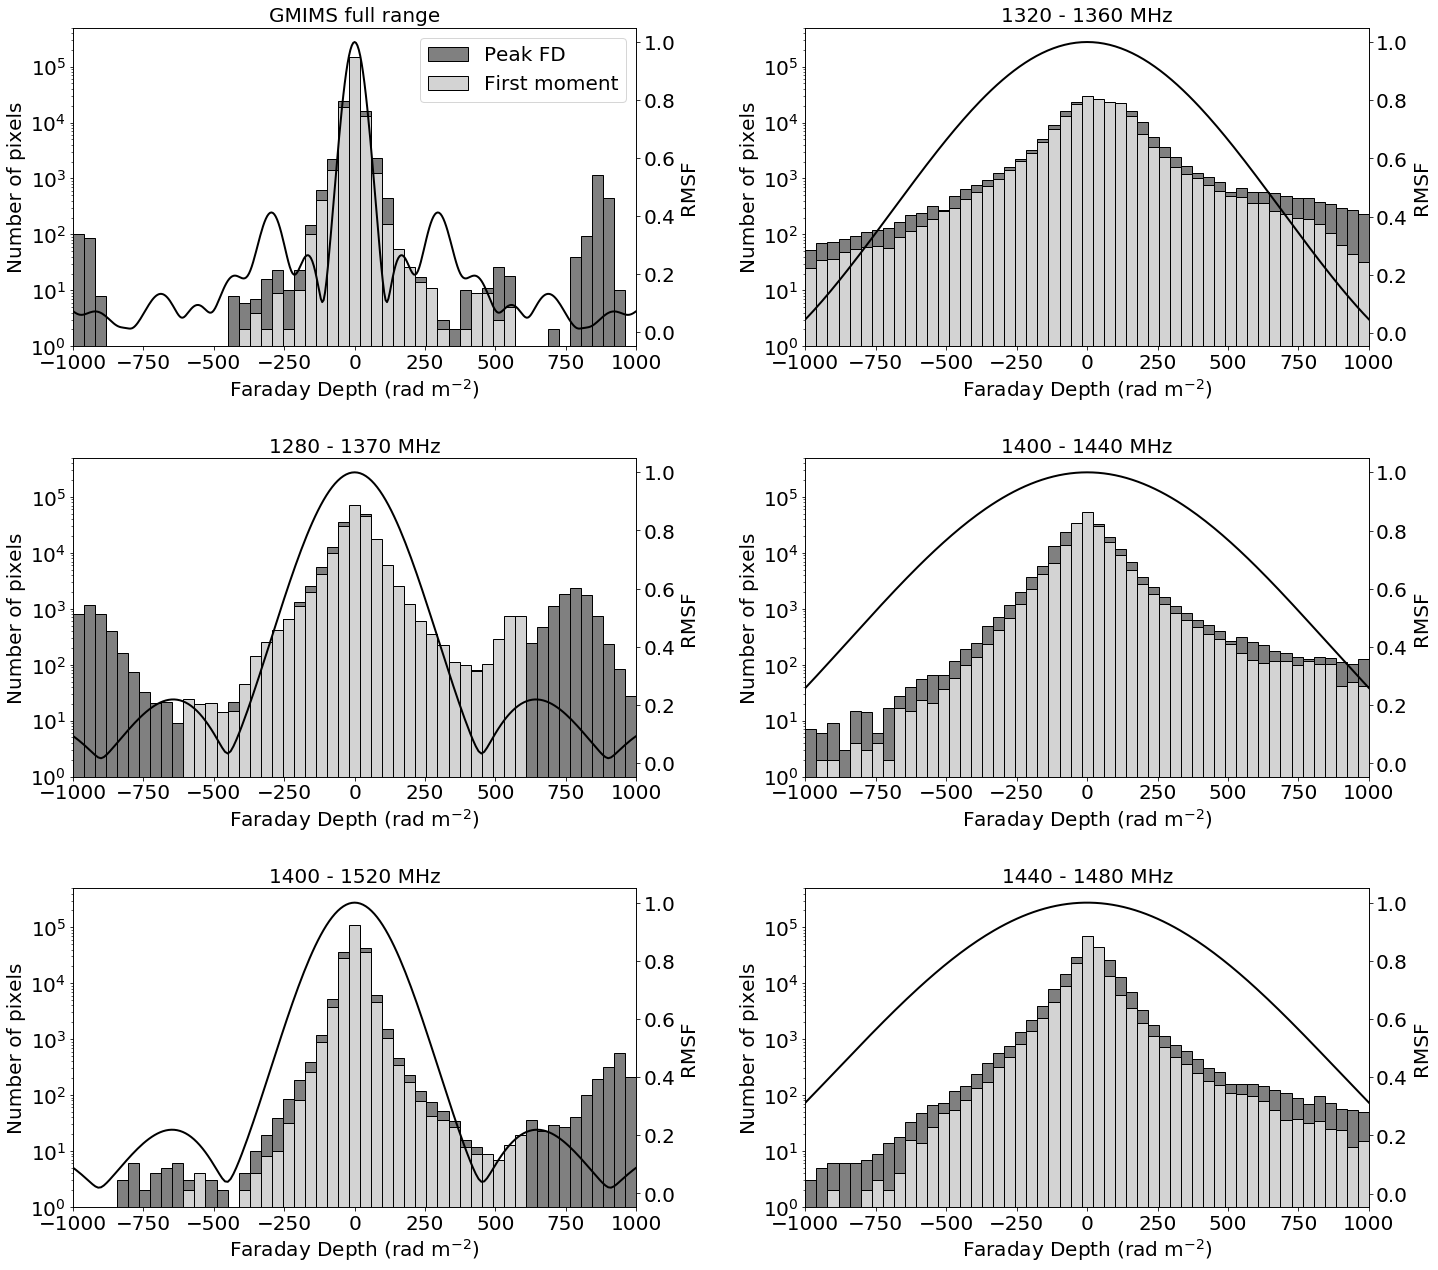

In [100]:
RMlim = 1000.
RMlim_pl = 1000.
numbins = 51

names = ('GMIMS full range', 
         '1280 - 1370 MHz',
         '1400 - 1520 MHz',
         '1320 - 1360 MHz',
         '1400 - 1440 MHz', 
         '1440 - 1480 MHz')

subplots = [321,323,325,322,324,326]

fs = 20

fig = plt.figure(figsize=(20,18))
plt.subplots_adjust(hspace=0.35,wspace=0.3,left=0.05,right=0.95,bottom=0.05,top=0.96)

print(dataRMSFs[1][:,0,0].shape)
print(RM_full_RMSF.shape)

 
ax = fig.add_subplot(321)
ax.hist(mapvec[0], range=(-RMlim,RMlim),bins=numbins,color='grey',
        edgecolor='black', linewidth=1.0,label='Peak FD')
ax.hist(mapvecM1[0], range=(-RMlim,RMlim),bins=numbins,color='lightgray',
        edgecolor='black', linewidth=1.0,label='First moment')
ax2 = ax.twinx()
ax2.plot(RM_full_RMSF,dataRMSFs[0][:,50,50],color='black',linewidth=2,label='RMSF')   
ax.set_yscale('log')
#ax2.set_yscale('log')
ax.set_xlim(-RMlim,RMlim)
ax.set_ylim(1,5e5)
ax.set_xlabel('Faraday Depth (rad m$^{-2}$)',fontsize=fs)
ax.set_ylabel('Number of pixels',fontsize=fs)
ax2.set_ylabel('RMSF',fontsize=fs)
ax.tick_params(axis='x', labelsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax2.tick_params(axis='y', labelsize=fs)
ax.legend(fontsize=fs)
ax.set_title(names[0],fontsize=fs)

for j in range(1,6):    
    i = subplots[j]    
    ax = fig.add_subplot(i)
    ax.hist(mapvec[j], range=(-RMlim,RMlim),bins=numbins,color='grey',
           edgecolor='black', linewidth=1.0)
    ax.hist(mapvecM1[j], range=(-RMlim,RMlim),bins=numbins,color='lightgrey',
           edgecolor='black', linewidth=1.0)
    ax2 = ax.twinx()
    ax2.plot(RM_mini_RMSF,dataRMSFs[j][:,50,50],color='black',linewidth=2)    
    ax.set_yscale('log')
    ax.set_ylim(1,5e5)
    #ax2.set_yscale('log')
    ax.set_xlim(-RMlim,RMlim)
    ax.set_xlabel('Faraday Depth (rad m$^{-2}$)',fontsize=fs)
    ax.set_ylabel('Number of pixels',fontsize=fs)
    ax2.set_ylabel('RMSF',fontsize=fs)
    ax.tick_params(axis='x', labelsize=fs)
    ax.tick_params(axis='y', labelsize=fs)
    ax2.tick_params(axis='y', labelsize=fs)
    ax.set_title(names[j],fontsize=fs)

plt.savefig('FIGURES/GMIMS_FREQ_RANGE_histograms.pdf')

In [43]:
freqs1 = np.array([1280,1400,1320,1400,1440])
freqs2 = np.array([1370,1520,1360,1440,1480])

lbd2_1 = ((3.0e8)/(freqs1*1e6))**2
lbd2_2 = ((3.0e8)/(freqs2*1e6))**2

lobewidth = 3.79/(lbd2_1-lbd2_2)

for i in range(0,5):
    print(freqs1[i],freqs2[i],round(lbd2_1[i],3),round(lbd2_1[i],3),round(lobewidth[i],1))

(1280, 1370, 0.055, 0.055, 543.0)
(1400, 1520, 0.046, 0.046, 544.2)
(1320, 1360, 0.052, 0.052, 1266.0)
(1400, 1440, 0.046, 0.046, 1506.6)
(1440, 1480, 0.043, 0.043, 1637.6)


(0.0, 50.0)
(0.0, 18.5)
(64.0, 5.0)
(148.0, 14.0)


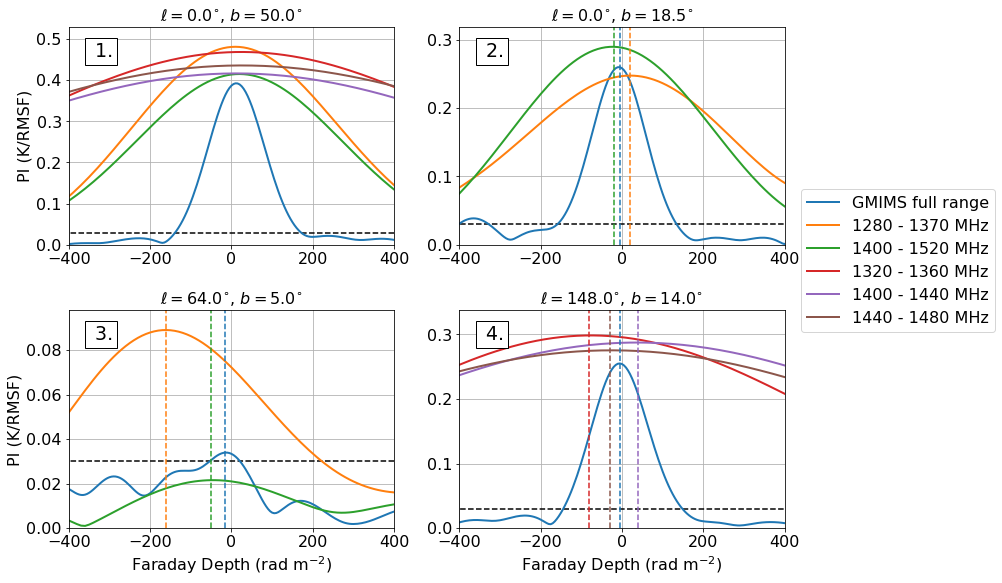

In [97]:
fs = 16

lonpts = [ 0.0, 0.0, 64., 148.]
latpts = [50.0, 18.5,5., 14.]

fig1, axs = plt.subplots(2,2,figsize=(14,8))
plt.subplots_adjust(bottom=0.08,top=0.95,left=0.07,right=0.78,wspace=0.2,hspace=0.3)

for i in range(0,2):
    axs[i,0].set_ylabel('PI (K/RMSF)',fontsize=fs)
    for j in range(0,2):
        k = 2*i+j
        wx = np.where(lon_full == lonpts[k])[0][0]
        wy = np.where(lat_full == latpts[k])[0][0]
        print(lon_full[wx],lat_full[wy])
        axs[i,j].plot([-2500,2500],[0.03,0.03],color='black',linestyle='dashed')
        
        if k == 0:
            axs[i,j].plot(RM_full,datacubes[0][:,wy,wx],linewidth=2,label=names[0])
            axs[i,j].plot(RM_mini,datacubes[1][:,wy,wx],linewidth=2,label=names[1])
            axs[i,j].plot(RM_mini,datacubes[2][:,wy,wx],linewidth=2,label=names[2])
            axs[i,j].plot(RM_mini,datacubes[3][:,wy,wx],linewidth=2,label=names[3])
            axs[i,j].plot(RM_mini,datacubes[4][:,wy,wx],linewidth=2,label=names[4])
            axs[i,j].plot(RM_mini,datacubes[5][:,wy,wx],linewidth=2,label=names[5])
        if ((k>0) & (k<3)):
            axs[i,j].plot(RM_full,datacubes[0][:,wy,wx],linewidth=2)
            axs[i,j].plot(RM_mini,datacubes[1][:,wy,wx],linewidth=2)
            axs[i,j].plot(RM_mini,datacubes[2][:,wy,wx],linewidth=2)
            w = np.where(datacubes[0][:,wy,wx]==PIpeaks[0,wy,wx])
            axs[i,j].plot([RM_full[w],RM_full[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C0')
            w = np.where(datacubes[1][:,wy,wx]==PIpeaks[1,wy,wx])
            axs[i,j].plot([RM_mini[w],RM_mini[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C1')
            w = np.where(datacubes[2][:,wy,wx]==PIpeaks[2,wy,wx])
            axs[i,j].plot([RM_mini[w],RM_mini[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C2')

        if k == 3:
            axs[i,j].plot(RM_full,datacubes[0][:,wy,wx],linewidth=2)
            axs[i,j].plot(RM_mini,datacubes[3][:,wy,wx],linewidth=2,color='C3')
            axs[i,j].plot(RM_mini,datacubes[4][:,wy,wx],linewidth=2,color='C4')
            axs[i,j].plot(RM_mini,datacubes[5][:,wy,wx],linewidth=2,color='C5')
            w = np.where(datacubes[0][:,wy,wx]==PIpeaks[0,wy,wx])
            axs[i,j].plot([RM_full[w],RM_full[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C0')
            w = np.where(datacubes[3][:,wy,wx]==PIpeaks[3,wy,wx])
            axs[i,j].plot([RM_mini[w],RM_mini[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C3')
            w = np.where(datacubes[4][:,wy,wx]==PIpeaks[4,wy,wx])
            axs[i,j].plot([RM_mini[w],RM_mini[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C4')
            w = np.where(datacubes[5][:,wy,wx]==PIpeaks[5,wy,wx])
            axs[i,j].plot([RM_mini[w],RM_mini[w]],[0,5.],linewidth=1.5,linestyle='dashed',color='C5')
        
        axs[i,j].set_xlim(-400,400)
        axs[i,j].set_ylim(0,1.1*max(PIpeaks[:,wy,wx]))
        axs[i,j].tick_params(axis="x", labelsize=fs) 
        axs[i,j].tick_params(axis="y", labelsize=fs)
        axs[i,j].grid()
        axs[i,j].text(-350, 0.95*max(PIpeaks[:,wy,wx]), ' '+str(k+1)+'.',fontsize=fs+3,
                      bbox=dict(facecolor='white', edgecolor='black'))
        axs[i,j].set_title('$\ell=$'+str(round(lon_full[wx],1))+'$^{\circ}$, $b=$'+
                           str(round(lat_full[wy],1))+'$^{\circ}$',fontsize=fs)
axs[1,0].set_xlabel('Faraday Depth (rad m$^{-2}$)',fontsize=fs)
axs[1,1].set_xlabel('Faraday Depth (rad m$^{-2}$)',fontsize=fs)
axs[0,0].legend(loc=(2.25,-0.4),fontsize=fs)

plt.savefig('FIGURES/sample_spectra_freq_ranges.pdf')